MODELE DE RESEAU DE NEURONES CONVOLUTIFS

In [1]:
'''
Modèle CNN avec Transfer Learning ResNet50

+ Découpage plus "propre" des jeux de données pour être sûr de n'avoir aucune photo dupliquée commune

'''

'\nModèle CNN avec Transfer Learning ResNet50\n\n+ Découpage plus "propre" des jeux de données pour être sûr de n\'avoir aucune photo dupliquée commune\n\n'

In [2]:
# Import des librairies principales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import re
from pathlib import Path

# Importation pour la transformation des images
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomContrast


# Imports nécessaires pour construire / sauvegarder / évaluer le modèle
#from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#rom tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras import regularizers

from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix



In [3]:
# Définition des chemins d'accès

rep_img = 'C:\\Users\\Utilisateur\\Documents\\DataScience_images_Especes\\'
rep_model = "C:\\Users\\Utilisateur\\Documents\\DataScience\\avr25cds_reconnaissance_champignons\\models\\"

In [ ]:
# Construction Datasets en évitant d'avoir une même photo dupliquée dans plusieurs jeux

# c-àd construction split train/val/test "groupé" par racine de photos
# Exemple : 705.jpg, 705_1.jpg, 705_2.jpg, 705_3.jpg => va dans le train
# 288.jpg, 288_1.jpg, 288_2.jpg, 288_3.jpg => va dans le test
# Afin que train et val n'aient pas de doublons et que le modèle ne voit pas du tout les photos du jeu de test



# Résumé du process :

# Liste des fichiers images => Groupes (1 groupe = même photo dupliquée plusieurs fois)
#  => Mélange des groupes => Split par groupe => création des 3 datasets images / label tf.data.Dataset



#  A/ Départ :
#    rep_img/
#       ├── classe_A/ (champignon de Paris par exemple)
#       │   ├── 705.jpg
#       │   ├── 705_1.jpg
#       │   ├── 705_2.jpg
#       │   ├── 812.jpg
#       │   └── ...
#       ├── classe_B/ (bolet par exemple)
#       │   ├── 1023.jpg
#       │   ├── 1023_1.jpg
#       │   └── ...
#       └── classe_C/ (chanterelle par exemple)
#       └── ...

# B/ Liste de toutes les photos "photos totales" :
#   photos_totales = [
#   rep_img/classe_A/705.jpg,
#   rep_img/classe_A/705_1.jpg,
#   rep_img/classe_A/705_2.jpg,
#   rep_img/classe_A/812.jpg,
#   rep_img/classe_B/1023.jpg,
#   rep_img/classe_B/1023_1.jpg,
#   ...
#   ]

rep_img_path = Path(rep_img) #pour pouvoir appliquer rglob, recherch par extension

exts = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}
photos_totales = [p for p in rep_img_path.rglob("*") if p.is_file() and p.suffix.lower() in exts]


# C/ On défini les classes :

#   class_names = ["classe_A", "classe_B", "classe_C", ...]
#   En gros, Classes = noms de sous-dossiers 

class_names = sorted({p.parent.name for p in photos_totales if p.parent.parent == rep_img_path})

# Indexation des classes pour les futurs tris et opérations
#   class_to_idx = {
#       "classe_A": 0,
#       "classe_B": 1,
#       "classe_C": 2,
#       ...
#       }

class_to_idx = {c: i for i, c in enumerate(class_names)}


# D/ Création des groupes 


# classe_A/705.jpg
# classe_A/705_1.jpg
# classe_A/705_2.jpg
# = 1 groupe

# et à la fin :
#   groups = {
#       "classe_A::705": [
#       705.jpg, 705_1.jpg, 705_2.jpg
#       ],
#       "classe_A::812": [
#       812.jpg
#       ],
#       "classe_B::1023": [
#       1023.jpg, 1023_1.jpg
#       ],
#       ...
#   }


# Pattern pour détecter base_id:
# 705.jpg, 705_1.jpg, 705_12.jpg -> base_id = "705"
# On prend la base sans extension, puis on enlève l'itération numérotée si elle est présente

# Avec pathlib on a :
#   p = Path("rep_img/classe_A/705_3.jpg")
#   p.name ="705_3.jpg"
#   p.suffix = ".jpg"
#   p.stem = "705_3"

dup_suffix_re = re.compile(r"^(?P<base>.+?)(?:_(?P<n>\d+))?$") # testé sur regex101.com

def base_id_from_path(p: Path) -> str:
    stem = p.stem  # "705_3"
    m = dup_suffix_re.match(stem)
    base = m.group("base") if m else stem
    # clé de groupe = (classe, base) pour éviter de grouper à tort entre classes
    return f"{p.parent.name}::{base}"


# Grouper les fichiers par base_id
groups = {}
for p in photos_totales:
    # on ignore ce qui n'est pas dans rep_img/<classe>/...
    if p.parent.parent != rep_img_path:
        continue
    cls = p.parent.name
    if cls not in class_to_idx:
        continue
    gid = base_id_from_path(p)
    groups.setdefault(gid, []).append(str(p))


#E/ Mélange par groupes

#   group_ids = [
#       "classe_A::705",
#       "classe_A::812",
#       "classe_B::1023",
#       ...
#       ]
#   shuffle(group_ids, seed=42)

group_ids = np.array(sorted(groups.keys()))
rng = np.random.default_rng(42)
rng.shuffle(group_ids)

#F/ Split par groupe

#   TRAIN : [classe_A::705, classe_C::411, ...]
#   VAL   : [classe_A::812, classe_B::900, ...]
#   TEST  : [classe_B::1023, classe_C::777, ...]

# Avec group_ids (mélangés)
#           ├── train_g (70%)
#           ├── val_g   (15%)
#           └── test_g  (15%)


# Split 70/15/15 par groupes racines des images
n = len(group_ids)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
train_g = set(group_ids[:n_train]) 
val_g   = set(group_ids[n_train:n_train + n_val])
test_g  = set(group_ids[n_train + n_val:])




# G/ Pour vérifier que deux ensembles n’ont aucun élément en commun
print(train_g.isdisjoint(val_g))
print(train_g.isdisjoint(test_g))
print(val_g.isdisjoint(test_g))

assert train_g.isdisjoint(val_g)
assert train_g.isdisjoint(test_g)
assert val_g.isdisjoint(test_g)


# H / Fonction permettant de transformer les groupes d'images en liste utilisable par tf.data
def expand_groups(gset):
    paths = []
    labels = []
    for gid in gset:
        files = groups[gid]
        # classe = avant "::"
        cls = gid.split("::", 1)[0]
        y = class_to_idx[cls]
        paths.extend(files)
        labels.extend([y] * len(files))
    return np.array(paths), np.array(labels, dtype=np.int32)

train_paths, train_labels = expand_groups(train_g)
val_paths,   val_labels   = expand_groups(val_g)
test_paths,  test_labels  = expand_groups(test_g)

print("Nb images total:", len(train_paths) + len(val_paths) + len(test_paths))
print("Train images:", len(train_paths), "Val images:", len(val_paths), "Test images:", len(test_paths))
print("Nb classes:", len(class_names))



# Construction des datasets

# Paramètres
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE    # Optimisation automatique du nombre de fichiers et threads à charger

# FOnction pour lire et preprocesser les images
def load_and_preprocess(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    return img, label

# Fonction pour creer les datasets
def make_ds(paths, labels, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        # Shuffle avant map pour un meilleur mélange
        ds = ds.shuffle(buffer_size=min(len(paths), 10000), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_labels, training=True)
val_ds   = make_ds(val_paths,   val_labels,   training=False)
test_ds  = make_ds(test_paths,  test_labels,  training=False)

print("Nb batchs dans train:", tf.data.experimental.cardinality(train_ds).numpy()) # nb de batch de 64 images
print("Nb batchs dans val  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Nb batch dans test :", tf.data.experimental.cardinality(test_ds).numpy())

Nb images total: 19216
Train images: 13436 Val images: 2950 Test images: 2830
Nb classes: 30
Nb batchs dans train: 210
Nb batchs dans val  : 47
Nb batch dans test : 45


In [5]:
# Définition des couches de transformation
random_translation = RandomTranslation(0.1, 0.1)   # Étirement
random_zoom = RandomZoom(0.1)                      # Agrandissement
random_flip = RandomFlip("horizontal")             # Retournement horizontal
random_rotation = RandomRotation(0.1)              # Rotation
random_contrast = RandomContrast(0.1)              # Contraste

In [6]:
# Création du pipe

NUM_CLASSES = 30

inputs = Input(shape=(224, 224, 3))

# Data augmentation
x = random_translation(inputs)
x = random_zoom(x)
x = random_flip(x)
x = random_rotation(x)
x = random_contrast(x)

# Préprocess ResNet50 (à la place du Rescaling)
x = preprocess_input(x)

# Backbone ResNet50
base_model = ResNet50(
    include_top=False,          # on enlève la couche de classification ImageNet
    weights="imagenet",
    input_tensor=x
)

base_model.trainable = False    # phase 1 : on gèle

# Tête de classification
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model_resnet = Model(inputs, outputs)



In [7]:
# Callback pour sauvegarder le modèle
'''save = ModelCheckpoint(
                        rep_model+'CNN_TL2_model.h5',
                        save_best_only=True, 
                        monitor='val_loss',
                        mode='min'
                    )'''


save = tf.keras.callbacks.ModelCheckpoint(
    rep_model + "CNN_TL2_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True
)



# Callback pour réduire le taux d'apprentissage
reduceLR = ReduceLROnPlateau(
                                monitor="val_loss",
                                mode="min",
                                patience=3,
                                factor=0.5,
                                min_delta=0.001,
                                cooldown=1,
                                min_lr=1e-6,
                                verbose=1
                                    )

# Callback pour stopper l'apprentissage quand il ne progresse plus
early_stop = EarlyStopping(
                                patience=6,     # Nombre d'époques sans amélioration avant arrêt
                                min_delta=0.001, 
                                mode='min',
                                monitor='val_loss',    # On surveille la perte sur l'ensemble de validation
                                restore_best_weights=True)

In [8]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [9]:
history_model1 = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,                  # 15 voire 20
    callbacks=[reduceLR, save, early_stop]
)

Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 175s 823ms/step - accuracy: 0.3808 - loss: 2.2812 - val_accuracy: 0.6031 - val_loss: 1.3532 - learning_rate: 0.0010
Epoch 2/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 172s 818ms/step - accuracy: 0.6791 - loss: 1.0681 - val_accuracy: 0.6346 - val_loss: 1.2137 - learning_rate: 0.0010
Epoch 3/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 172s 819ms/step - accuracy: 0.7509 - loss: 0.8306 - val_accuracy: 0.6586 - val_loss: 1.1699 - learning_rate: 0.0010
Epoch 4/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 172s 821ms/step - accuracy: 0.7917 - loss: 0.6853 - val_accuracy: 0.6505 - val_loss: 1.2571 - learning_rate: 0.0010
Epoch 5/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 172s 820ms/step - accuracy: 0.8206 - loss: 0.5711 - val_accuracy: 0.6736 - val_loss: 1.1928 - learning_rate: 0.0010
Epoch 6/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.8405 - loss: 0.5134
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
210/210 ━━━━━━━━━━━━━━━━━━━━ 172s 822ms/step - accuracy:

In [10]:
# Dégèle
base_model.trainable = True


fine_tune_at = 140  # ResNet50 a environ 175 couches
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


'''
# Pour dégeler la totalité :
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
'''

'\n# Pour dégeler la totalité :\nfor layer in base_model.layers:\n    if isinstance(layer, layers.BatchNormalization):\n        layer.trainable = False\n'

In [11]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [12]:
history_model2 = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[reduceLR, save, early_stop]
)

Epoch 1/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.8049 - loss: 0.6224 - val_accuracy: 0.6814 - val_loss: 1.2831 - learning_rate: 1.0000e-05
Epoch 2/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.8907 - loss: 0.3360 - val_accuracy: 0.6793 - val_loss: 1.3213 - learning_rate: 1.0000e-05
Epoch 3/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9188 - loss: 0.2735 - val_accuracy: 0.6868 - val_loss: 1.3115 - learning_rate: 1.0000e-05
Epoch 4/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.9258 - loss: 0.2375
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
210/210 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.9258 - loss: 0.2375 - val_accuracy: 0.6895 - val_loss: 1.3024 - learning_rate: 1.0000e-05
Epoch 5/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9403 - loss: 0.1997 - val_accuracy: 0.6902 - val_loss: 1.3081 - learning_rate: 5.0000e-06
Epoch 6/40
210/210 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accurac

In [13]:
np.save(rep_model+"CNN_TL2_model_history.npy", history_model2.history)

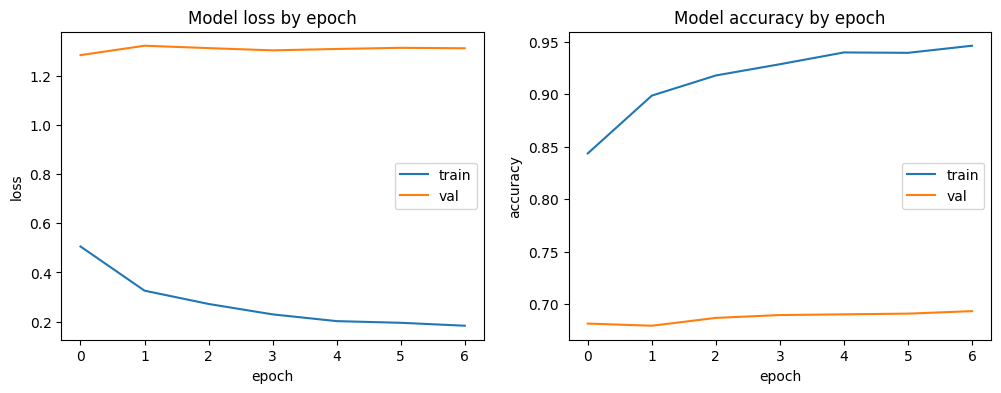

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(history_model2.history['loss'])
plt.plot(history_model2.history['val_loss'])
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='right')

plt.subplot(122)
plt.plot(history_model2.history['accuracy'])
plt.plot(history_model2.history['val_accuracy'])
plt.title('Model accuracy by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='right')
plt.show()

In [15]:
# Fonction pour obtenir les prédictions

def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model_resnet.predict(images, verbose=0)
        pred_labels.extend(np.argmax(preds, axis=-1))

        true_labels.extend(labels.numpy())

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)     # test, pas val

# Afficher le rapport de classification
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.41      0.56       100
           1       0.57      0.74      0.65        84
           2       0.80      0.76      0.78       163
           3       0.61      0.73      0.67       147
           4       0.51      0.61      0.56       113
           5       0.72      0.74      0.73       107
           6       0.96      0.79      0.87        98
           7       0.44      0.86      0.59       143
           8       0.79      0.90      0.84        49
           9       0.86      0.45      0.59        69
          10       0.83      0.82      0.83       135
          11       0.98      0.78      0.87        74
          12       0.80      0.78      0.79        99
          13       0.80      0.90      0.85       173
          14       0.63      0.61      0.62        67
          15       0.81      0.84      0.82        73
          16       0.84      0.75      0.79        56
          17       0.94    

<Axes: >

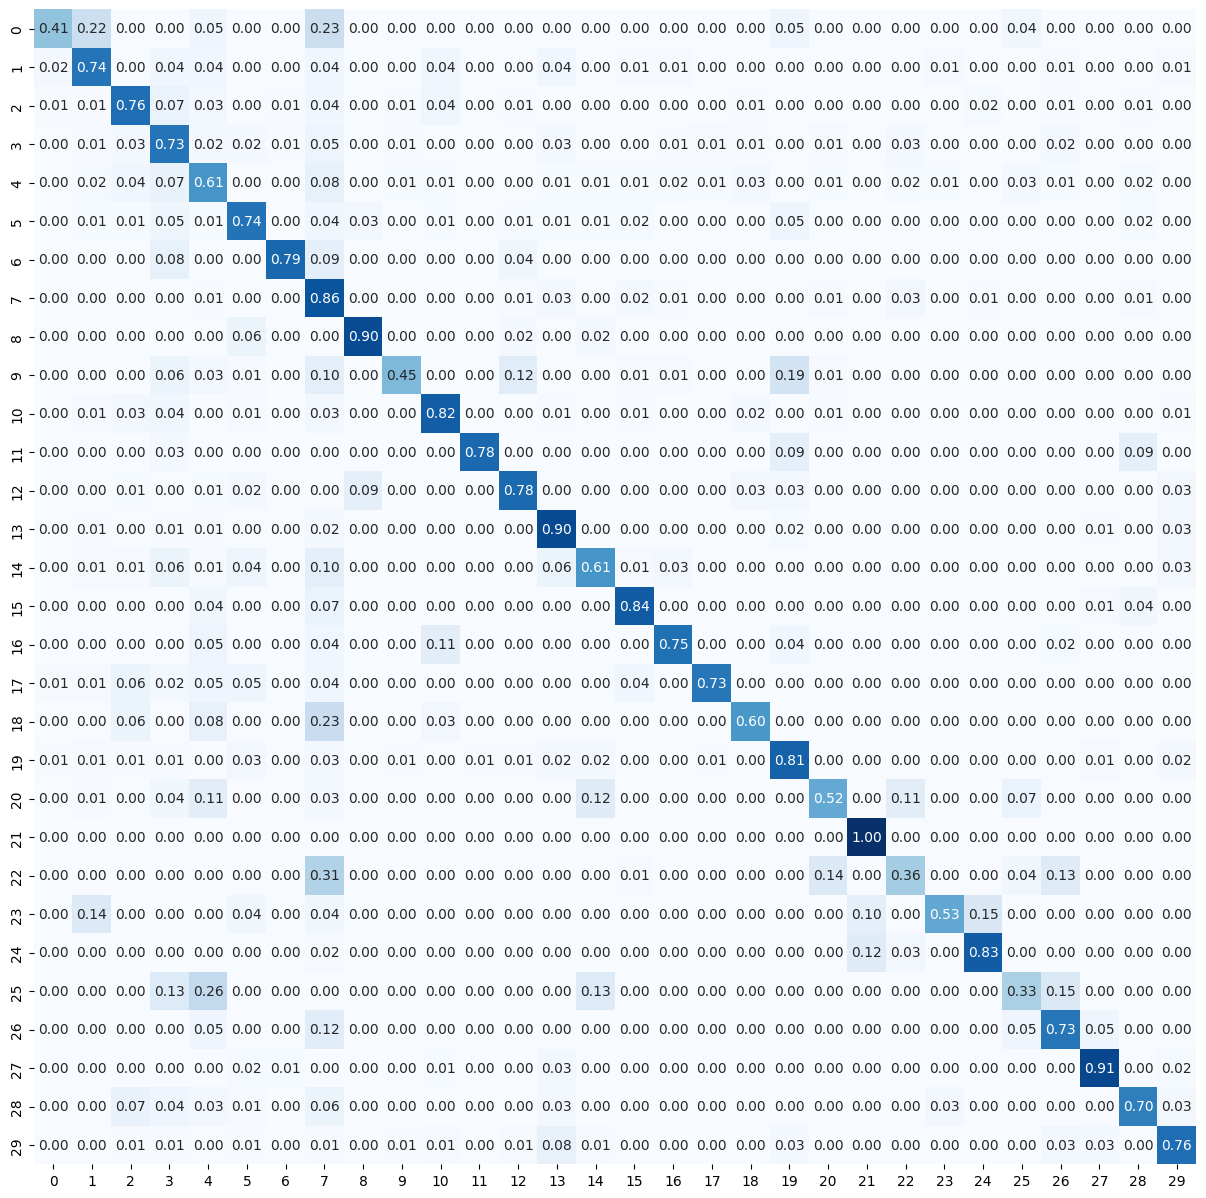

In [ ]:
# Affichage de la matrice de confusion "Rappel" (normalisée par ligne, normalize = 'true')
plt.figure(figsize=(15, 15))
cnf_matrix_rf = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cnf_matrix_rf, cmap='Blues', annot=True, cbar=False, fmt=".2f")

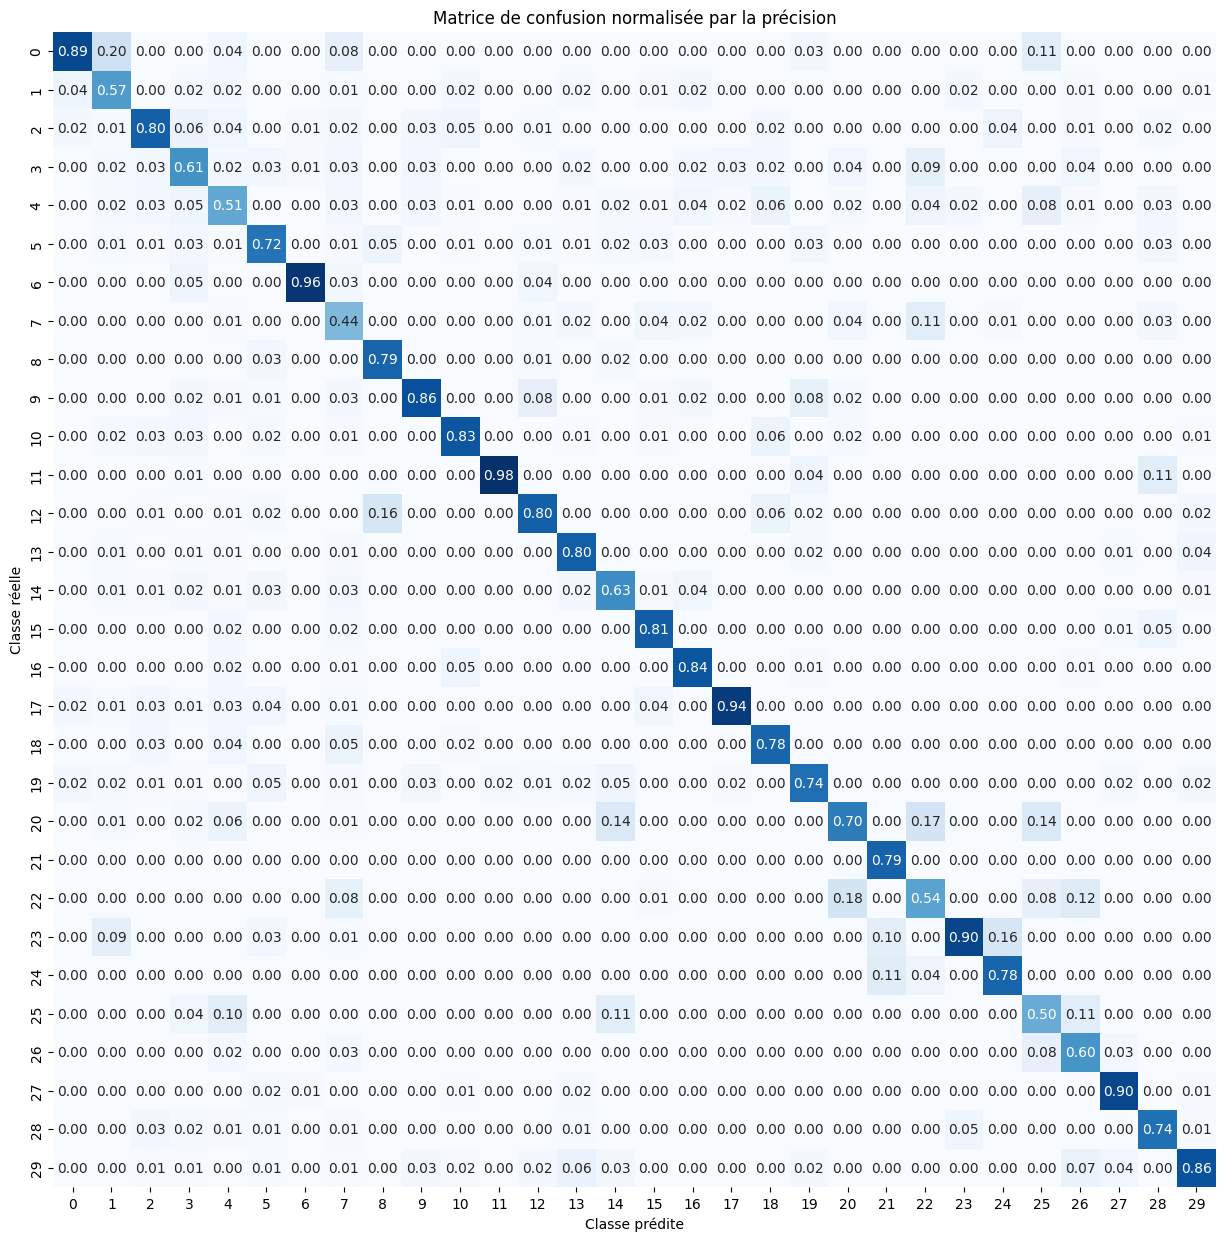

In [ ]:
# Affichage de la matrice de confusion "Précision" (normalisée par colonne, normalize = 'pred')
plt.figure(figsize=(15, 15))
cnf_matrix_rf = confusion_matrix(y_true, y_pred, normalize='pred')
sns.heatmap(cnf_matrix_rf, cmap='Blues', annot=True, cbar=False, fmt=".2f")
